**Unsupervised learning** is a type of machine learning that discovers hidden patterns and structures in **unlabeled data**. A primary example of this is **clustering**, where algorithms like **k-means** automatically group similar data points together without any pre-existing labels to guide them.

## Supervised vs. Unsupervised Learning

The fundamental difference between the two machine learning paradigms lies in the data they use and the goals they aim to achieve.

  * **Supervised Learning**: This is "learning with an answer key." The algorithm is trained on a labeled dataset, meaning it has access to both the input **features** and the correct output **target**. Its goal is to learn a mapping function to make accurate **predictions** on new data.

  * **Unsupervised Learning**: This is "learning without an answer key." The algorithm is given only the input **features** and must discover inherent patterns, structures, or relationships within the data on its own. Its goal is **pattern discovery** and data representation. The two main tasks in unsupervised learning are:

      * **Clustering**: Grouping similar data points together.
      * **Dimensionality Reduction**: Compressing the data by finding a more efficient representation of its features.

### k-Means Clustering

**k-Means clustering** is one of the most popular and intuitive clustering algorithms. Its objective is to partition a dataset into `k` distinct, non-overlapping clusters.

  * **The Goal**: To group the data points such that the total variance within each cluster is minimized. Each data point is assigned to the cluster whose mean (or **centroid**) is closest.
  * **The "k" Hyperparameter**: A key aspect of k-means is that `k`, the number of clusters, is a **hyperparameter** that you must specify *before* the algorithm runs.

The algorithm works by iteratively assigning data points to the nearest centroid and then updating the centroid's position to be the mean of the points assigned to it, repeating this process until the cluster assignments stabilize.

### Clustering with `scikit-learn`

Let's walk through a complete example of performing k-means clustering on the well-known Iris dataset. Although this dataset has true labels (the species), we will ignore them and see if the unsupervised algorithm can rediscover these natural groupings on its own.

```python
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

# 1. Load and Prepare the Data
# The Iris dataset contains measurements for 3 species of iris flowers.
iris = load_iris()
# We use only the features for our unsupervised task.
samples = iris.data

# 2. Instantiate and Fit the k-Means Model
# We specify k=3 because we have a prior belief that there are three groups (species).
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(samples)

# 3. Get the Cluster Labels for the Training Data
# The .labels_ attribute contains the cluster assignment for each sample.
predicted_labels = kmeans.labels_

# 4. Predict on New, Unseen Data
# The trained model can now assign new samples to the learned clusters.
new_samples = np.array([
    [5.7, 4.4, 1.5, 0.4], # Likely a Setosa
    [6.5, 3.0, 5.5, 1.8], # Likely a Virginica
    [5.8, 2.7, 4.1, 1.0]  # Likely a Versicolor
])
new_labels = kmeans.predict(new_samples)
print(new_labels)

# 5. Visualize the Clustering Results
# We create a DataFrame for easier plotting with seaborn.
df = pd.DataFrame(samples, columns=iris.feature_names)
df['predicted_cluster'] = predicted_labels
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('k-Means Clustering vs. True Species Labels', fontsize=16)

# Plot 1: Points colored by the k-means predicted cluster
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='predicted_cluster',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Clusters Found by k-Means')

# Plot 2: Points colored by the actual species
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Actual Species Labels')

plt.show()
```

**Interpretation**:
The side-by-side comparison is striking. The plot on the left shows the three distinct clusters that the k-means algorithm discovered purely from the geometric arrangement of the data points. The plot on the right shows the true species labels. We can see that the unsupervised algorithm did an excellent job of rediscovering the underlying species structure in the data without ever being told what a "Setosa" or "Versicolor" was. This demonstrates the power of unsupervised learning to find meaningful patterns in data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [12]:
from data.points import points

xs = points[:, 0]
ys = points[:, 1]

display(points)

array([[ 0.06544649, -0.76866376],
       [-1.52901547, -0.42953079],
       [ 1.70993371,  0.69885253],
       [ 1.16779145,  1.01262638],
       [-1.80110088, -0.31861296],
       [-1.63567888, -0.02859535],
       [ 1.21990375,  0.74643463],
       [-0.26175155, -0.62492939],
       [-1.61925804, -0.47983949],
       [-1.84329582, -0.16694431],
       [ 1.35999602,  0.94995827],
       [ 0.42291856, -0.7349534 ],
       [-1.68576139,  0.10686728],
       [ 0.90629995,  1.09105162],
       [-1.56478322, -0.84675394],
       [-0.0257849 , -1.18672539],
       [ 0.83027324,  1.14504612],
       [ 1.22450432,  1.35066759],
       [-0.15394596, -0.71704301],
       [ 0.86358809,  1.06824613],
       [-1.43386366, -0.2381297 ],
       [ 0.03844769, -0.74635022],
       [-1.58567922,  0.08499354],
       [ 0.6359888 , -0.58477698],
       [ 0.24417242, -0.53172465],
       [-2.19680359,  0.49473677],
       [ 1.0323503 , -0.55688   ],
       [-0.28858067, -0.39972528],
       [ 0.20597008,

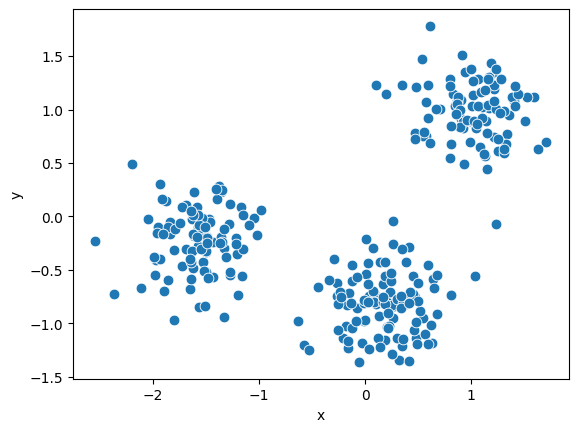

In [32]:
points_df = pd.DataFrame(points, columns=["x", "y"])


sns.scatterplot(data=points_df, x="x", y="y", s=60)
plt.show()

In [27]:
from sklearn.cluster import KMeans
from data.new_points import new_points

# Create a KMeans instance with 3 clusters: model
kmeans = KMeans(n_clusters=3)

# Fit model to points

kmeans.fit(points)

labels_points = kmeans.predict(points)

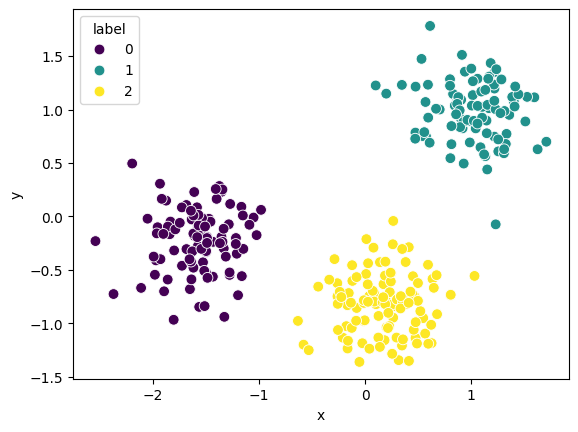

In [28]:
points_df = pd.DataFrame(points, columns=["x", "y"])
points_df["label"] = labels_points

sns.scatterplot(data=points_df, x="x", y="y", hue="label", palette="viridis", s=60)
plt.show()

In [30]:
# Determine the cluster labels of new_points: labels
labels_new_points = kmeans.predict(new_points)

# make a DataFrame tying new_points to their predicted labels, then plot
new_points_df = pd.DataFrame(new_points, columns=["x", "y"])
new_points_df["label"] = labels_new_points

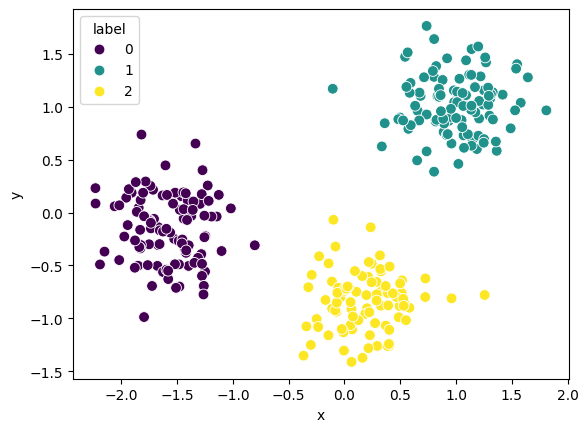

In [31]:
sns.scatterplot(data=new_points_df, x="x", y="y", hue="label", palette="viridis", s=60)
# optionally overlay kmeans centroids from the trained model

plt.show()

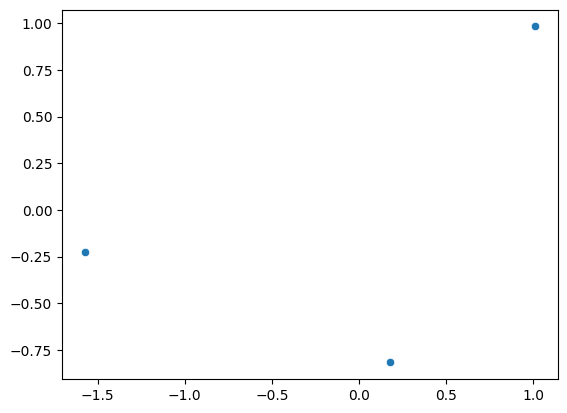

In [36]:
# Assign the cluster centers: centroids
centroids = kmeans.cluster_centers_

# Assign the columns of centroids: centroids_x, centroids_y
centroids_x = centroids[:, 0]
centroids_y = centroids[:, 1]

# Make a scatter plot of centroids_x and centroids_y
sns.scatterplot(x=centroids_x, y=centroids_y)
plt.show()

**Evaluating a clustering involves assessing its quality, either by comparing the discovered clusters to known ground truth labels using a cross-tabulation or, more commonly, by using an intrinsic metric like inertia to measure the compactness of the clusters. This intrinsic measure is crucial for guiding the selection of the optimal number of clusters via techniques like the elbow method.**

## The Two Paradigms of Cluster Evaluation

Once a clustering algorithm has partitioned the data, you need to determine how "good" the result is. This evaluation can be approached in two ways, depending on whether you have access to the "correct" answers.

1.  **Extrinsic Evaluation**: This is possible only when you have ground truth labels for your data (e.g., the actual species for the Iris flowers). You can then compare the algorithm's cluster assignments to these true labels to see how well they align. This is a measure of how accurately the clustering has recovered a known underlying structure.

2.  **Intrinsic Evaluation**: This is the more common scenario in unsupervised learning, where no ground truth labels exist. The evaluation must be based solely on the structure of the data and the clusters themselves. Intrinsic metrics typically measure the **compactness** (how close points are within a cluster) and **separation** (how far apart different clusters are).

### Extrinsic Evaluation with Cross-Tabulation

When ground truth labels are available, a **cross-tabulation** (or contingency table) is an excellent tool for comparing the predicted cluster labels against the true labels. It shows the distribution of samples at the intersection of each cluster and each true category.

#### Example: Comparing Iris Clusters to True Species

Let's continue with the Iris dataset, where we have the true species. We can build a cross-tabulation to see how well our 3-cluster solution corresponds to the 3 actual species.



In [38]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load, scale, and cluster the Iris data
iris = load_iris()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(iris.data)
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(features_scaled)

# 2. Create a DataFrame for comparison
comparison_df = pd.DataFrame(
    {"cluster_label": cluster_labels, "true_species": iris.target_names[iris.target]}
)

# 3. Generate the cross-tabulation
cross_tab = pd.crosstab(comparison_df["cluster_label"], comparison_df["true_species"])

print("Cross-Tabulation of Cluster Labels vs. True Species:")
display(cross_tab)

Cross-Tabulation of Cluster Labels vs. True Species:


true_species,setosa,versicolor,virginica
cluster_label,,,
0,0,46,50
1,33,0,0
2,17,4,0


This table is highly informative. We can see that Cluster 0 perfectly corresponds to the *setosa* species. Cluster 1 has captured almost all of the *versicolor* samples, and Cluster 2 has captured the majority of the *virginica* samples, with some known overlap between the two.



### Intrinsic Evaluation with Inertia and the Elbow Method

In most cases, we don't have true labels. We must rely on an intrinsic metric to guide us. For k-means, the most important metric is **inertia**.

**Inertia** is the sum of squared distances of each sample to its closest cluster centroid.
$$Inertia = \sum_{i=0}^{n} \min_{\mu_j \in C}(||x_i - \mu_j||^2)$$
where $\mu_j$ is the centroid for cluster $j$.

In simple terms, **inertia measures the internal cohesion or tightness of the clusters**. A lower inertia means the clusters are more compact and dense, which is generally better. The k-means algorithm itself tries to find centroids that minimise this value.

### Finding the Optimal Number of Clusters (`k`)

While lower inertia is better, the metric will *always* decrease as you add more clusters (`k`). A clustering where every point is its own cluster would have an inertia of zero but would be useless. The goal is to find a balance: a low inertia value with a reasonably small number of clusters.

The **Elbow Method** is a popular heuristic for finding this balance. The process involves:

1.  Running k-means for a range of different `k` values.
2.  Plotting `k` against the inertia for each run.
3.  Looking for an "elbow" in the plot—the point where the rate of decrease in inertia slows down dramatically. This point represents a good trade-off.

### Example: Generating an Elbow Plot

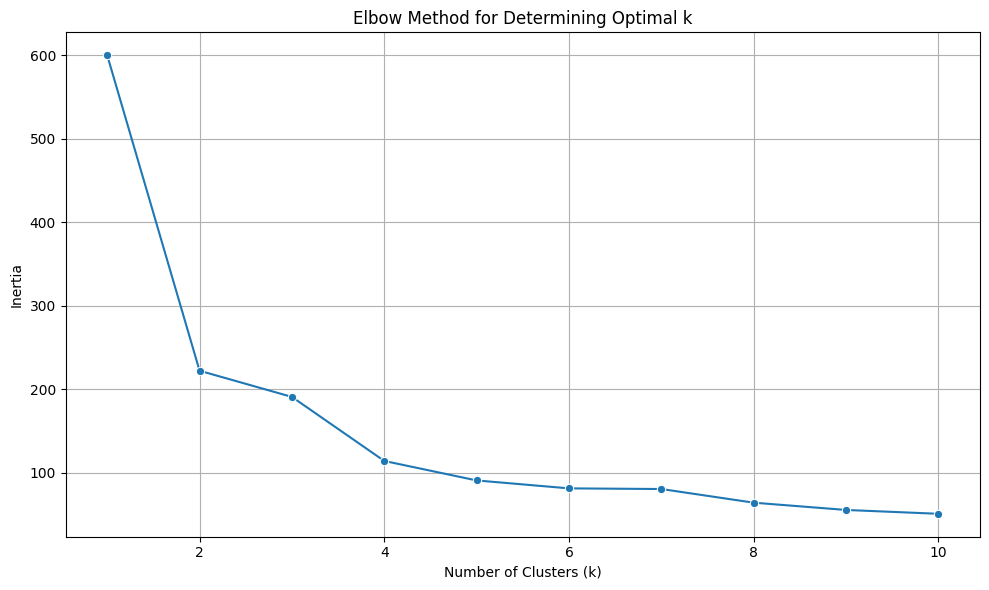

In [43]:
# Using the scaled Iris features from the previous example
k_range = range(1, 11)
inertia_values = []

# Run k-means for each value of k and store the inertia
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(features_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=list(k_range), y=inertia_values, marker="o", ax=ax)
ax.set_title("Elbow Method for Determining Optimal k")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.grid(True)

plt.tight_layout()
plt.show()

The plot clearly shows that the inertia decreases sharply from k=1 to k=2, and again from k=2 to k=3. After k=3, the decrease becomes much more gradual. This distinct "elbow" at **k=3** suggests that it is the optimal number of clusters for the Iris dataset, which aligns with our extrinsic knowledge that there are three species.

In [ ]:
seeds = pd.read_txt()